<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 2: Variables aleatorias y muestreo
        </td>
    </tr>
    <tr>
 

</table>

## Ejercicio - Clase 03 - 06-02-2026

In [2]:
import pandas as pd
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from scipy.stats import truncnorm

Simular lo siguiente:

- Una muestra $\varepsilon$ de $n = 500$ de una distribución de Laplace con media $\mu = 0$ y decrecimiento $\sigma=1$.
- Una muestra $x$ de $n = 500$ de una distribución exponencial con tasa $\theta = 1/50$

Construir las muestras $Y1$ e $Y2$ que sean igual a:
\begin{align*}
Y1&=100+2x+ \varepsilon x \\
Y2&=100+2x+\varepsilon
\end{align*}

- Obtener un modelo de regresión lineal $Y = \beta_0 + \beta_1 x$ para $Y1$ e $Y2$ y
representa gráficamente los residuos de los modelos
- Realiza la prueba de Breusch-Pagan para cada uno de los modelos

In [3]:
#Definir semilla para que los resultados sean los mismos
np.random.seed(seed = 20231085)

#Se obtiene la muestra de la distribución de Laplace
mu = 0 
sigma = 5
n = 500
muestra_laplace = np.random.laplace(mu,sigma,n)

#Se obtiene la muestra de la distribución exponencial
theta = 1/50 
muestra_exp = np.random.exponential(theta, n)

In [5]:
# Se construye la muestra y1
#y1 = 100+2x+ex
#e = laplace, x = exponencial
y1 = 100+2*muestra_laplace * muestra_exp

#Se necesita trasponer el vector x
x = muestra_exp.reshape((-1, 1))
lm1 = linear_model.LinearRegression()
model1 = lm1.fit(x, y1)

#Obtener valores modelo
y_pred1 = model1.predict(x)
#Obtener residuos
residuos1 = y1 - y_pred1

#Se construye la muestra y2
y2 = 100+2*muestra_laplace + muestra_exp
lm2 = linear_model.LinearRegression()
model2 = lm2.fit(x, y2)

#Obtener valores modelo
y_pred2 = model2.predict(x)
#Obtener residuos
residuos2 = y2 - y_pred2

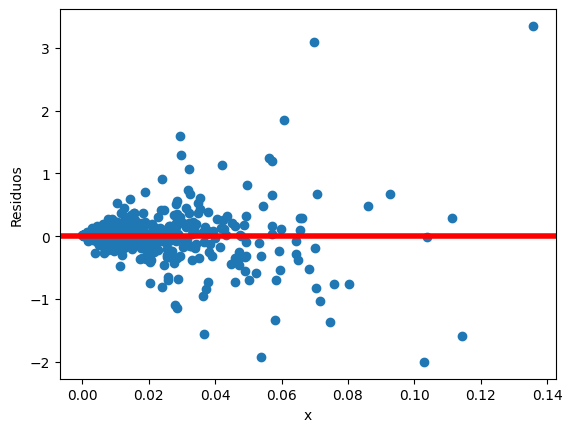

In [6]:
#Obtención de las gráficas
plt.scatter(x, residuos1)
plt.axhline(0, color = "red", linewidth = 4)
plt.xlabel("x")
plt.ylabel("Residuos")
plt.show()

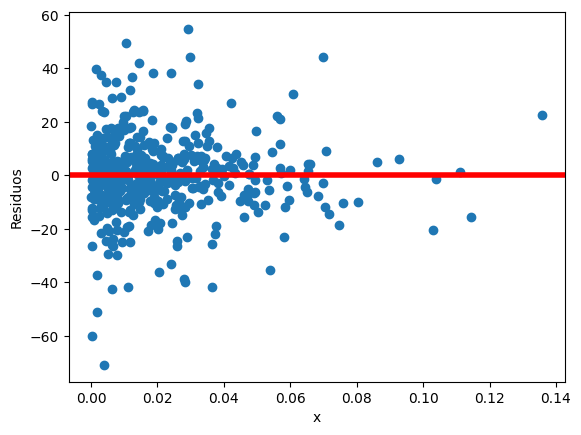

In [7]:
plt.scatter(x, residuos2)
plt.axhline(0, color = "red", linewidth = 4)
plt.xlabel("x")
plt.ylabel("Residuos")
plt.show()

In [14]:
#Realización de las pruebas de homocedasticidad

In [8]:
m1 = sm.OLS(y1, sm.add_constant(x)).fit()
bp1 = sms.het_breuschpagan(resid = m1.resid, exog_het = m1.model.exog)[1]
print("El resultado del test Breusch-Pagan es: p.valor = %5.3f"%(bp1))

El resultado del test Breusch-Pagan es: p.valor = 0.000


In [9]:
m2 = sm.OLS(y2, sm.add_constant(x)).fit()
bp2 = sms.het_breuschpagan(resid = m2.resid, exog_het = m2.model.exog)[1]
print("El resultado del test Breusch-Pagan es: p.valor = %5.3f"%(bp2))

El resultado del test Breusch-Pagan es: p.valor = 0.597
